## Image Data Analysis

In [1]:
import sys
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use('default')
from PIL import Image

IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    PROJECT_ROOT = Path('/content/drive/MyDrive/dissertation')
else:
    PROJECT_ROOT = Path('..').resolve()

DATA_ROOT = PROJECT_ROOT / 'CGMacros'
OUT_DIR = PROJECT_ROOT / 'dataset' / 'analysis_outputs' / 'meal_outputs'
# NATIVE_DIR = PROJECT_ROOT / 'dataset' /'native_cgm'
OUT_DIR.mkdir(parents=True, exist_ok=True)
# NATIVE_DIR.mkdir(parents=True, exist_ok=True)

print(f"IN_COLAB={IN_COLAB}  \nDATA_ROOT={DATA_ROOT}  \nOUT_DIR={OUT_DIR}")

IN_COLAB=False  
DATA_ROOT=/Users/ucabtt4/Projects/Dissertation/dissertation/CGMacros  
OUT_DIR=/Users/ucabtt4/Projects/Dissertation/dissertation/dataset/analysis_outputs/meal_outputs


In [2]:
summary = {}  # collected across every section below, saved once at the very end

cgm_root = DATA_ROOT
all_pids = sorted(d.name for d in cgm_root.iterdir() if d.is_dir() and d.name.startswith('CGMacros-'))

bio = pd.read_csv(DATA_ROOT / 'bio.csv')
bio['participant_id'] = bio['subject'].apply(lambda s: f'CGMacros-{s:03d}')
bio['group'] = bio['A1c PDL (Lab)'].apply(
    lambda a: 'Healthy' if a < 5.7 else ('Prediabetes' if a < 6.5 else 'Type2Diabetes'))
bio = bio.set_index('participant_id')

EXCLUDE_PIDS = {'CGMacros-007', 'CGMacros-018', 'CGMacros-026'}  # see cgm_characteristics.ipynb
kept_pids = [p for p in all_pids if p not in EXCLUDE_PIDS]

print(f'{len(all_pids)} participant folders found, {len(kept_pids)} kept (matching '
      f'cgm_characteristics.ipynb)')

45 participant folders found, 42 kept (matching cgm_characteristics.ipynb)


#### 1. Meal-event and Photos availability

In [3]:
# Harmonise Meal Type labels for descriptive summaries only
MEAL_TYPE_MAP = {
    'breakfast': 'Breakfast',
    'lunch': 'Lunch',
    'dinner': 'Dinner',
    'snack': 'Snack',
    'snacks': 'Snack',
    'snack 1': 'Snack',
}

meal_records = []
participant_rows = []

for pid in kept_pids:
    df = pd.read_csv(
        cgm_root / pid / f'{pid}.csv',
        usecols=['Timestamp', 'Meal Type', 'Image path']
    )
    df['Timestamp'] = pd.to_datetime(df['Timestamp'])

    meals = df[df['Meal Type'].notna()].copy()
    meals['meal_type_clean'] = (
        meals['Meal Type'].astype(str).str.strip().str.lower().map(MEAL_TYPE_MAP)
    )
    meals['participant_id'] = pid
    meals['has_photo'] = meals['Image path'].notna()
    meal_records.append(meals)

    participant_rows.append({
        'participant_id': pid,
        'group': bio.loc[pid, 'group'],
        'n_meals': len(meals),
        'n_meals_with_photo': int(meals['has_photo'].sum()),
        'n_meals_without_photo': int((~meals['has_photo']).sum()),
        'n_photo_records': int(df['Image path'].notna().sum()),
    })

meal_events = pd.concat(meal_records, ignore_index=True)
participant_meal = pd.DataFrame(participant_rows).set_index('participant_id')

n_meals = int(participant_meal['n_meals'].sum())
n_with = int(participant_meal['n_meals_with_photo'].sum())
n_without = int(participant_meal['n_meals_without_photo'].sum())
n_photo_records = int(participant_meal['n_photo_records'].sum())
coverage = 100 * n_with / n_meals

print('--- Retained analytical cohort (n=42) ---')
print(f'Logged meal events: {n_meals}')
print(f'Meal events with an attached photo: {n_with} ({coverage:.1f}%)')
print(f'Meal events without an attached photo: {n_without} ({100-coverage:.1f}%)')
print(f'All CSV photo records (tagged + untagged): {n_photo_records}')

print('\n--- Harmonised meal types ---')
print(meal_events['meal_type_clean'].value_counts(dropna=False))

summary['retained_meal_photo_coverage'] = {
    'n_participants': len(kept_pids),
    'n_meals': n_meals,
    'n_meals_with_photo': n_with,
    'n_meals_without_photo': n_without,
    'pct_meals_with_photo': float(coverage),
    'n_csv_photo_records': n_photo_records,
    'meal_type_counts': meal_events['meal_type_clean'].value_counts(dropna=False).to_dict(),
}


--- Retained analytical cohort (n=42) ---
Logged meal events: 1614
Meal events with an attached photo: 1556 (96.4%)
Meal events without an attached photo: 58 (3.6%)
All CSV photo records (tagged + untagged): 3040

--- Harmonised meal types ---
meal_type_clean
Dinner       465
Breakfast    411
Lunch        410
Snack        328
Name: count, dtype: int64


In [4]:
# Group-level availability table
group_order = ['Healthy', 'Prediabetes', 'Type2Diabetes']

group_summary = (
    participant_meal.reset_index()
    .groupby('group')
    .agg(
        participants=('participant_id', 'nunique'),
        meal_events=('n_meals', 'sum'),
        meals_with_photo=('n_meals_with_photo', 'sum'),
        meals_without_photo=('n_meals_without_photo', 'sum'),
        photo_records=('n_photo_records', 'sum'),
        mean_meals_per_participant=('n_meals', 'mean'),
        mean_photos_per_participant=('n_photo_records', 'mean'),
    )
    .reindex(group_order)
)
group_summary['meal_photo_coverage_pct'] = (
    100 * group_summary['meals_with_photo'] / group_summary['meal_events']
)

print(group_summary.round(1).to_string())
summary['meal_photo_by_group'] = group_summary.reset_index().to_dict(orient='records')


               participants  meal_events  meals_with_photo  meals_without_photo  photo_records  mean_meals_per_participant  mean_photos_per_participant  meal_photo_coverage_pct
group                                                                                                                                                                           
Healthy                  14          595               576                   19           1106                        42.5                         79.0                     96.8
Prediabetes              14          564               538                   26           1125                        40.3                         80.4                     95.4
Type2Diabetes            14          455               442                   13            809                        32.5                         57.8                     97.1


#### Participant-level balance

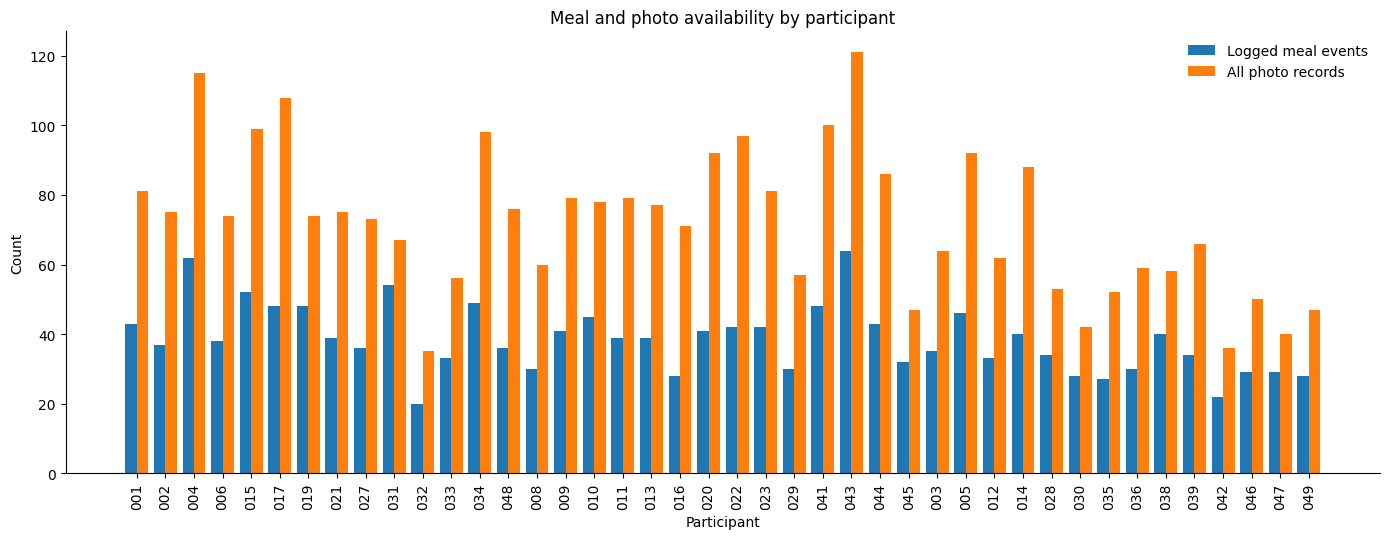

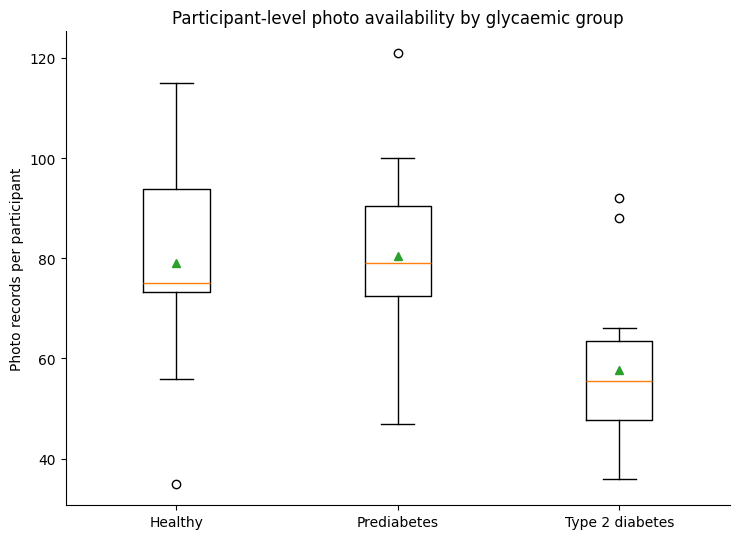

In [14]:
# Participant-level meal and photo counts
plt.style.use('default')
plot_df = participant_meal.reset_index().copy()
plot_df['pid_num'] = plot_df['participant_id'].str.extract(r'(\d+)$').astype(int)
plot_df = plot_df.sort_values(['group', 'pid_num'])

fig, ax = plt.subplots(figsize=(14, 5.5), facecolor='white')
x = np.arange(len(plot_df))
ax.bar(x - 0.2, plot_df['n_meals'], width=0.4, label='Logged meal events')
ax.bar(x + 0.2, plot_df['n_photo_records'], width=0.4, label='All photo records')
ax.set_xticks(x)
ax.set_xticklabels(plot_df['participant_id'].str.replace('CGMacros-', ''), rotation=90)
ax.set_xlabel('Participant')
ax.set_ylabel('Count')
ax.set_title('Meal and photo availability by participant')
ax.legend(frameon=False)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig(OUT_DIR / 'meal_photo_counts_by_participant.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

# Distribution of photo records by group
fig, ax = plt.subplots(figsize=(7.5, 5.5), facecolor='white')
data = [participant_meal.loc[participant_meal['group'] == g, 'n_photo_records'].values for g in group_order]
ax.boxplot(data, tick_labels=['Healthy', 'Prediabetes', 'Type 2 diabetes'], showmeans=True)
ax.set_ylabel('Photo records per participant')
ax.set_title('Participant-level photo availability by glycaemic group')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig(OUT_DIR / 'photo_counts_by_group.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()


#### 2. Raw image archive integrity and properties

In [6]:
# ============================================================
# IMAGE CHARACTERISTICS
# Final and consistent version
#
# Two populations:
#   A. All physical photographs from retained 42 participants
#   B. Meal-associated photographs from retained 42 participants
#      (Meal Type present AND Image path present)
#
# IMPORTANT:
#   - Every physical file is checked, no sampling
#   - File integrity is verified with PIL
#   - EXIF orientation is corrected BEFORE width/height and
#     Portrait/Landscape classification
#   - The same definition is used for both populations
# ============================================================

from pathlib import Path
from PIL import Image, ImageOps
import pandas as pd
import numpy as np


# ============================================================
# 0. Helper functions
# ============================================================

def resolve_image_path(pid, image_path):
    """
    Resolve an Image path stored in the participant CSV.

    Handles both cases such as:
        photos/example.jpg
    and:
        example.jpg
    """

    image_path = str(image_path)
    candidate = cgm_root / pid / image_path

    if candidate.exists():
        return candidate

    candidate = cgm_root / pid / 'photos' / Path(image_path).name

    if candidate.exists():
        return candidate

    # Return the expected path even if it does not exist,
    # so that missing references can be reported explicitly.
    return cgm_root / pid / image_path


def inspect_image_records(records, label):
    """
    Inspect every UNIQUE physical image in records.

    Required columns:
        participant_id
        path

    Image integrity:
        checked on the original file using PIL.verify()

    Image dimensions/orientation:
        measured AFTER applying EXIF orientation correction.
    """

    records = records.copy()

    # --------------------------------------------------------
    # Remove duplicate references to exactly the same file
    # --------------------------------------------------------
    records['path'] = records['path'].apply(Path)

    records = (
        records
        .drop_duplicates(
            subset=['participant_id', 'path']
        )
        .reset_index(drop=True)
    )

    inspected = []
    failed = []
    missing = []

    for _, row in records.iterrows():

        pid = row['participant_id']
        path = Path(row['path'])

        # ----------------------------------------------------
        # Check that the referenced file actually exists
        # ----------------------------------------------------
        if not path.is_file():

            missing.append({
                'participant_id': pid,
                'filename': path.name,
                'path': str(path)
            })

            continue

        try:

            # =================================================
            # Step 1: verify physical file integrity
            # =================================================
            with Image.open(path) as img:
                img.verify()

            # =================================================
            # Step 2: reopen file for actual measurements
            # =================================================
            with Image.open(path) as img:

                # Save format BEFORE exif_transpose because
                # ImageOps can return a new PIL object whose
                # .format may become None.
                image_format = img.format

                # Correct phone/camera EXIF orientation
                corrected = ImageOps.exif_transpose(img)

                width = corrected.width
                height = corrected.height
                image_mode = corrected.mode

            # =================================================
            # Orientation based on EXIF-corrected dimensions
            # =================================================
            if height > width:
                orientation = 'Portrait'

            elif width > height:
                orientation = 'Landscape'

            else:
                orientation = 'Square'

            inspected.append({
                'participant_id': pid,
                'filename': path.name,
                'path': str(path),

                'format': image_format,
                'mode': image_mode,

                'orientation': orientation,

                'width': int(width),
                'height': int(height),

                'size_bytes': int(path.stat().st_size)
            })

        except Exception as e:

            failed.append({
                'participant_id': pid,
                'filename': path.name,
                'path': str(path),
                'error': str(e)
            })

    inspected_df = pd.DataFrame(inspected)
    failed_df = pd.DataFrame(failed)
    missing_df = pd.DataFrame(missing)

    # ========================================================
    # Print overall summary
    # ========================================================

    print('\n' + '=' * 70)
    print(label)
    print('=' * 70)

    print(f'Unique image files requested: {len(records)}')
    print(f'Successfully verified: {len(inspected_df)}')
    print(f'Missing referenced files: {len(missing_df)}')
    print(f'Failed/corrupted files: {len(failed_df)}')

    if len(inspected_df) == 0:
        return inspected_df, failed_df, missing_df

    print(
        f'Participants represented: '
        f'{inspected_df["participant_id"].nunique()}'
    )

    print(
        f'Formats: '
        f'{inspected_df["format"].value_counts(dropna=False).to_dict()}'
    )

    print(
        f'Modes: '
        f'{inspected_df["mode"].value_counts(dropna=False).to_dict()}'
    )

    orientation_counts = (
        inspected_df['orientation']
        .value_counts()
    )

    orientation_pct = (
        100 *
        orientation_counts /
        len(inspected_df)
    )

    print('\nOrientations:')

    for orientation in [
        'Portrait',
        'Landscape',
        'Square'
    ]:

        n = int(
            orientation_counts.get(
                orientation, 0
            )
        )

        pct = float(
            orientation_pct.get(
                orientation, 0
            )
        )

        if n > 0:
            print(
                f'  {orientation}: '
                f'{n} ({pct:.1f}%)'
            )

    print('\nOverall dimensions:')

    print(
        f'  Width (px): '
        f'mean={inspected_df["width"].mean():.0f}, '
        f'median={inspected_df["width"].median():.0f}, '
        f'range={inspected_df["width"].min()}–'
        f'{inspected_df["width"].max()}'
    )

    print(
        f'  Height (px): '
        f'mean={inspected_df["height"].mean():.0f}, '
        f'median={inspected_df["height"].median():.0f}, '
        f'range={inspected_df["height"].min()}–'
        f'{inspected_df["height"].max()}'
    )

    print(
        f'  File size (KB): '
        f'mean={inspected_df["size_bytes"].mean()/1024:.0f}, '
        f'median={inspected_df["size_bytes"].median()/1024:.0f}, '
        f'range={inspected_df["size_bytes"].min()/1024:.0f}–'
        f'{inspected_df["size_bytes"].max()/1024:.0f}'
    )

    # ========================================================
    # Dimensions separately by orientation
    # ========================================================

    print('\nDimensions by orientation:')

    for orientation in [
        'Portrait',
        'Landscape',
        'Square'
    ]:

        sub = inspected_df[
            inspected_df['orientation']
            == orientation
        ]

        if len(sub) == 0:
            continue

        print(
            f'\n  {orientation}: '
            f'n={len(sub)} '
            f'({100*len(sub)/len(inspected_df):.1f}%)'
        )

        print(
            f'    Width (px): '
            f'mean={sub["width"].mean():.0f}, '
            f'median={sub["width"].median():.0f}, '
            f'range={sub["width"].min()}–'
            f'{sub["width"].max()}'
        )

        print(
            f'    Height (px): '
            f'mean={sub["height"].mean():.0f}, '
            f'median={sub["height"].median():.0f}, '
            f'range={sub["height"].min()}–'
            f'{sub["height"].max()}'
        )

        print(
            f'    File size (KB): '
            f'mean={sub["size_bytes"].mean()/1024:.0f}, '
            f'median={sub["size_bytes"].median()/1024:.0f}, '
            f'range={sub["size_bytes"].min()/1024:.0f}–'
            f'{sub["size_bytes"].max()/1024:.0f}'
        )

    return inspected_df, failed_df, missing_df


# ============================================================
# 1. ALL physical photographs
#    Retained 42 participants
# ============================================================

all_42_records = []

for pid in kept_pids:

    photo_dir = cgm_root / pid / 'photos'

    if not photo_dir.is_dir():
        continue

    for path in sorted(photo_dir.iterdir()):

        if not path.is_file():
            continue

        all_42_records.append({
            'participant_id': pid,
            'path': path
        })


all_42_records = pd.DataFrame(all_42_records)


all42_images_df, all42_failed_df, all42_missing_df = (
    inspect_image_records(
        all_42_records,
        label=(
            'A. ALL PHYSICAL FOOD PHOTOGRAPHS '
            '— RETAINED 42 PARTICIPANTS'
        )
    )
)


# ============================================================
# 2. MEAL-ASSOCIATED photographs
#    Retained 42 participants
#
# Definition:
#     Meal Type is not missing
#     AND
#     Image path is not missing
#
# This is the subset most relevant to the multimodal model.
# ============================================================

meal_image_records = []

meal_event_rows = []


for pid in kept_pids:

    csv_path = (
        cgm_root /
        pid /
        f'{pid}.csv'
    )

    df = pd.read_csv(
        csv_path,
        usecols=[
            'Meal Type',
            'Image path'
        ]
    )

    # --------------------------------------------------------
    # All logged meal events
    # --------------------------------------------------------

    meals = df[
        df['Meal Type'].notna()
    ].copy()

    # --------------------------------------------------------
    # Logged meals with attached image
    # --------------------------------------------------------

    meals_with_image = meals[
        meals['Image path'].notna()
    ].copy()

    meal_event_rows.append({
        'participant_id': pid,
        'n_meal_events': len(meals),
        'n_meal_events_with_image':
            len(meals_with_image)
    })

    # --------------------------------------------------------
    # Resolve every meal-associated image reference
    # --------------------------------------------------------

    for image_path in meals_with_image[
        'Image path'
    ]:

        resolved = resolve_image_path(
            pid,
            image_path
        )

        meal_image_records.append({
            'participant_id': pid,
            'path': resolved
        })


meal_image_records = pd.DataFrame(
    meal_image_records
)

meal_event_df = pd.DataFrame(
    meal_event_rows
)


# ============================================================
# 3. Meal-photo coverage
# ============================================================

n_meals = int(
    meal_event_df[
        'n_meal_events'
    ].sum()
)

n_meals_with_image = int(
    meal_event_df[
        'n_meal_events_with_image'
    ].sum()
)

meal_photo_coverage = (
    100 *
    n_meals_with_image /
    n_meals
)


print('\n' + '=' * 70)
print('MEAL-PHOTO COVERAGE — RETAINED 42 PARTICIPANTS')
print('=' * 70)

print(
    f'Logged meal events: '
    f'{n_meals}'
)

print(
    f'Meal events with attached image: '
    f'{n_meals_with_image}'
)

print(
    f'Meal events without attached image: '
    f'{n_meals - n_meals_with_image}'
)

print(
    f'Meal-photo coverage: '
    f'{meal_photo_coverage:.1f}%'
)


# ============================================================
# 4. Inspect the actual meal-associated photographs
# ============================================================

meal_images_df, meal_images_failed_df, meal_images_missing_df = (
    inspect_image_records(
        meal_image_records,
        label=(
            'B. MEAL-ASSOCIATED FOOD PHOTOGRAPHS '
            '— RETAINED 42 PARTICIPANTS'
        )
    )
)


# ============================================================
# 5. Sanity checks
# ============================================================

print('\n' + '=' * 70)
print('SANITY CHECKS')
print('=' * 70)

print(
    f'Retained participants expected: 42'
)

print(
    f'Participants with physical images: '
    f'{all42_images_df["participant_id"].nunique()}'
)

print(
    f'Participants with meal-associated images: '
    f'{meal_images_df["participant_id"].nunique()}'
)

print(
    f'\nAll physical images: '
    f'{len(all42_images_df)}'
)

print(
    f'Meal-associated UNIQUE images: '
    f'{len(meal_images_df)}'
)

print(
    f'Meal-event rows with attached image: '
    f'{n_meals_with_image}'
)

print(
    f'\nDuplicate meal-image references removed: '
    f'{n_meals_with_image - len(meal_images_df)}'
)

print(
    f'Missing meal-image files: '
    f'{len(meal_images_missing_df)}'
)

print(
    f'Corrupted meal-image files: '
    f'{len(meal_images_failed_df)}'
)


# ============================================================
# 6. Save detailed outputs
# ============================================================

all42_images_df.to_csv(
    OUT_DIR /
    'image_properties_all_physical_retained42.csv',
    index=False
)

meal_images_df.to_csv(
    OUT_DIR /
    'image_properties_meal_associated_retained42.csv',
    index=False
)

meal_event_df.to_csv(
    OUT_DIR /
    'meal_photo_coverage_retained42.csv',
    index=False
)


# ============================================================
# 7. Save clean summary
# ============================================================

def make_image_summary(df, failed_df, missing_df):

    orientation_counts = (
        df['orientation']
        .value_counts()
        .to_dict()
    )

    orientation_pct = (
        100 *
        df['orientation']
        .value_counts() /
        len(df)
    ).to_dict()

    return {

        'n_images': int(len(df)),

        'n_participants':
            int(
                df[
                    'participant_id'
                ].nunique()
            ),

        'n_failed':
            int(len(failed_df)),

        'n_missing':
            int(len(missing_df)),

        'format_counts':
            df[
                'format'
            ].value_counts(
                dropna=False
            ).to_dict(),

        'mode_counts':
            df[
                'mode'
            ].value_counts(
                dropna=False
            ).to_dict(),

        'orientation_counts':
            orientation_counts,

        'orientation_percent':
            orientation_pct,

        'width_px': {
            'mean':
                float(df['width'].mean()),
            'median':
                float(df['width'].median()),
            'min':
                int(df['width'].min()),
            'max':
                int(df['width'].max())
        },

        'height_px': {
            'mean':
                float(df['height'].mean()),
            'median':
                float(df['height'].median()),
            'min':
                int(df['height'].min()),
            'max':
                int(df['height'].max())
        },

        'file_size_kb': {
            'mean':
                float(
                    df[
                        'size_bytes'
                    ].mean() / 1024
                ),
            'median':
                float(
                    df[
                        'size_bytes'
                    ].median() / 1024
                ),
            'min':
                float(
                    df[
                        'size_bytes'
                    ].min() / 1024
                ),
            'max':
                float(
                    df[
                        'size_bytes'
                    ].max() / 1024
                )
        }
    }


summary[
    'all_physical_images_retained42'
] = make_image_summary(
    all42_images_df,
    all42_failed_df,
    all42_missing_df
)


summary[
    'meal_associated_images_retained42'
] = make_image_summary(
    meal_images_df,
    meal_images_failed_df,
    meal_images_missing_df
)


summary[
    'meal_photo_coverage_retained42'
] = {
    'n_participants': 42,

    'n_meal_events':
        int(n_meals),

    'n_meal_events_with_image':
        int(n_meals_with_image),

    'n_meal_events_without_image':
        int(
            n_meals -
            n_meals_with_image
        ),

    'coverage_percent':
        float(
            meal_photo_coverage
        ),

    'n_unique_meal_associated_images':
        int(
            len(meal_images_df)
        )
}


A. ALL PHYSICAL FOOD PHOTOGRAPHS — RETAINED 42 PARTICIPANTS
Unique image files requested: 3253
Successfully verified: 3253
Missing referenced files: 0
Failed/corrupted files: 0
Participants represented: 42
Formats: {'JPEG': 3253}
Modes: {'RGB': 3253}

Orientations:
  Portrait: 3134 (96.3%)
  Landscape: 119 (3.7%)

Overall dimensions:
  Width (px): mean=1029, median=900, range=198–2048
  Height (px): mean=1727, median=1600, range=236–2048
  File size (KB): mean=182, median=162, range=5–605

Dimensions by orientation:

  Portrait: n=3134 (96.3%)
    Width (px): mean=999, median=900, range=198–1585
    Height (px): mean=1753, median=1600, range=236–2048
    File size (KB): mean=181, median=161, range=5–605

  Landscape: n=119 (3.7%)
    Width (px): mean=1802, median=1600, range=1599–2048
    Height (px): mean=1061, median=1080, range=899–1512
    File size (KB): mean=206, median=187, range=55–536

MEAL-PHOTO COVERAGE — RETAINED 42 PARTICIPANTS
Logged meal events: 1614
Meal events with at

#### 3. Tagged and Untagged Photograph structure

In [7]:
pair_gaps = []
n_tagged_total = 0
n_untagged_total = 0
n_untagged_with_precursor = 0
photo_structure_rows = []

for pid in kept_pids:
    df = pd.read_csv(
        cgm_root / pid / f'{pid}.csv',
        usecols=['Timestamp', 'Meal Type', 'Image path']
    )
    df['Timestamp'] = pd.to_datetime(df['Timestamp'])
    photos = df[df['Image path'].notna()].sort_values('Timestamp')
    tagged = photos[photos['Meal Type'].notna()]
    untagged = photos[photos['Meal Type'].isna()]

    n_tagged_total += len(tagged)
    n_untagged_total += len(untagged)

    tagged_times = tagged['Timestamp'].values
    matched = 0
    for t in untagged['Timestamp']:
        prior = tagged_times[tagged_times <= t.to_datetime64()]
        if len(prior) == 0:
            continue
        gap_min = (t - pd.Timestamp(prior.max())).total_seconds() / 60
        if 0 <= gap_min <= 60:
            matched += 1
            pair_gaps.append(gap_min)

    photo_structure_rows.append({
        'participant_id': pid,
        'group': bio.loc[pid, 'group'],
        'n_tagged': len(tagged),
        'n_untagged': len(untagged),
        'n_untagged_with_prior_tagged_60min': matched,
    })

pair_gaps = pd.Series(pair_gaps, dtype=float)
photo_structure = pd.DataFrame(photo_structure_rows)

print('--- Retained analytical cohort (n=42) ---')
print(f'Tagged photo records (Meal Type present): {n_tagged_total}')
print(f'Untagged photo records (Meal Type absent): {n_untagged_total}')
print(f'Untagged photos within 60 min after a tagged photo: {n_untagged_with_precursor} '
      f'({100*n_untagged_with_precursor/n_untagged_total:.1f}% of untagged photos)')
print(f'Gap to preceding tagged photo: mean={pair_gaps.mean():.1f} min, '
      f'median={pair_gaps.median():.1f} min, '
      f'IQR={pair_gaps.quantile(.25):.1f}–{pair_gaps.quantile(.75):.1f} min')

summary['tagged_untagged_pattern_42'] = {
    'n_tagged': int(n_tagged_total),
    'n_untagged': int(n_untagged_total),
    'n_untagged_with_prior_tagged_within_60min': int(n_untagged_with_precursor),
    'pct_untagged_with_prior_tagged_within_60min': float(100*n_untagged_with_precursor/n_untagged_total),
    'gap_minutes_mean': float(pair_gaps.mean()),
    'gap_minutes_median': float(pair_gaps.median()),
    'gap_minutes_q25': float(pair_gaps.quantile(.25)),
    'gap_minutes_q75': float(pair_gaps.quantile(.75)),
}


--- Retained analytical cohort (n=42) ---
Tagged photo records (Meal Type present): 1556
Untagged photo records (Meal Type absent): 1484
Untagged photos within 60 min after a tagged photo: 0 (0.0% of untagged photos)
Gap to preceding tagged photo: mean=16.7 min, median=14.0 min, IQR=9.0–22.0 min


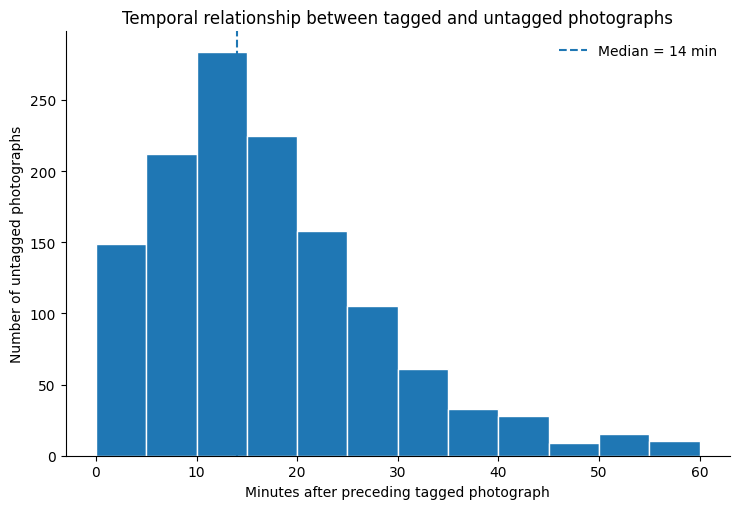

In [15]:
# Distribution of temporal gaps between untagged photos and preceding tagged photos
plt.style.use('default')
fig, ax = plt.subplots(figsize=(7.5, 5.2), facecolor='white')
ax.hist(pair_gaps, bins=np.arange(0, 65, 5), edgecolor='white')
ax.axvline(pair_gaps.median(), linestyle='--', linewidth=1.5,
           label=f'Median = {pair_gaps.median():.0f} min')
ax.set_xlabel('Minutes after preceding tagged photograph')
ax.set_ylabel('Number of untagged photographs')
ax.set_title('Temporal relationship between tagged and untagged photographs')
ax.legend(frameon=False)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig(OUT_DIR / 'tagged_untagged_time_gap.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()


#### 4. Visualize Food Photo

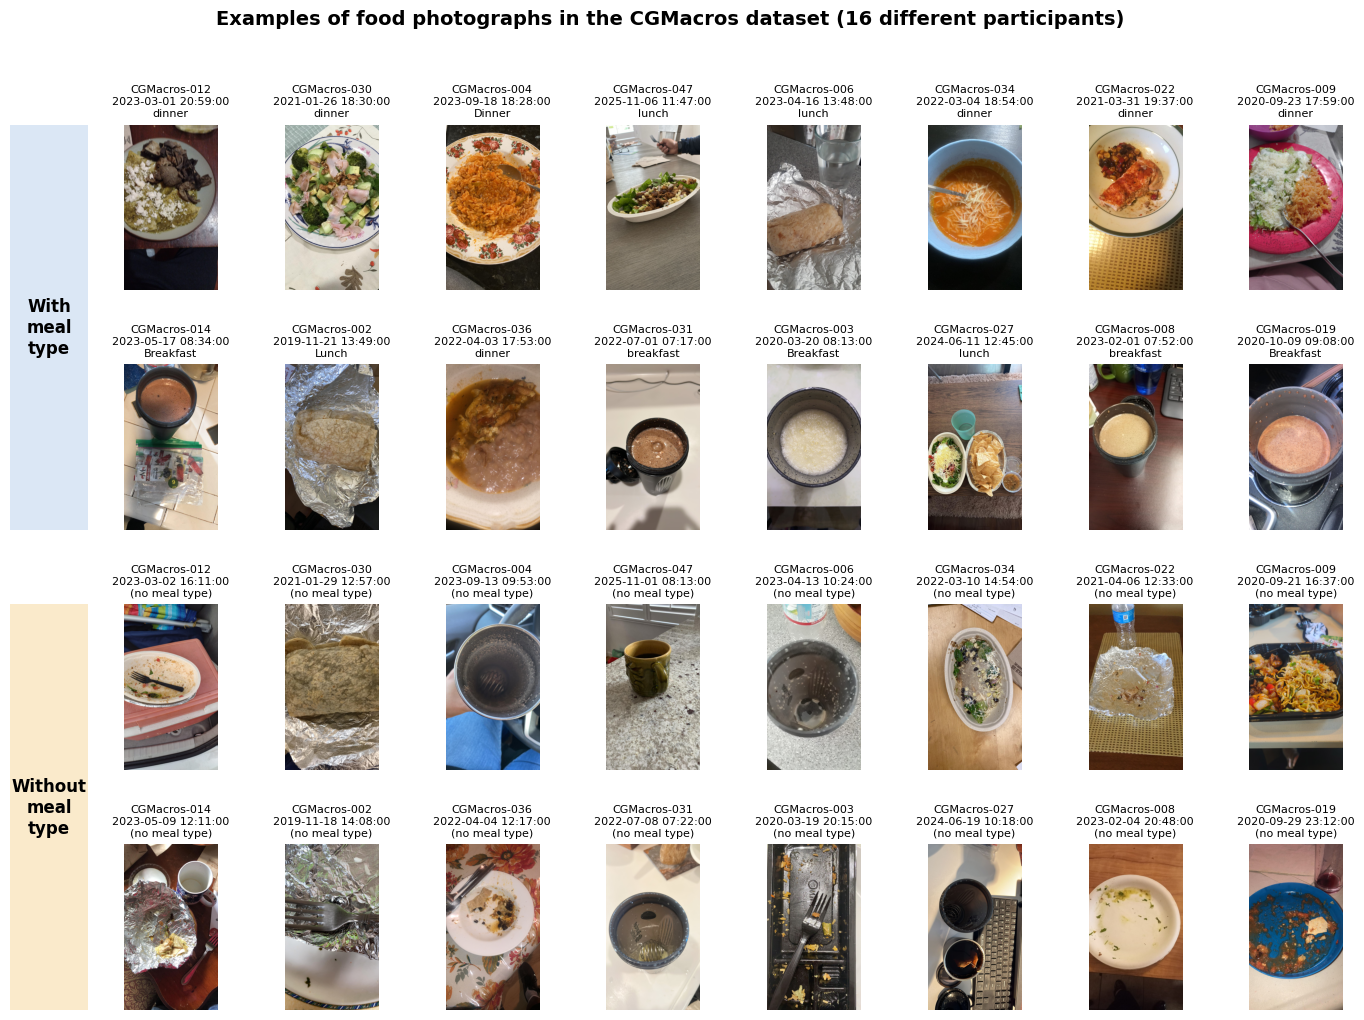

In [16]:
from PIL import ImageOps

def file_exists(pid, image_path):
    return (cgm_root / pid / image_path).exists()

def load_upright(pid, image_path):
    return ImageOps.exif_transpose(Image.open(cgm_root / pid / image_path))

def pick_random_portrait(df_candidates, pid, rng):
    order = df_candidates.sample(frac=1, random_state=int(rng.integers(1e9)))
    for _, row in order.iterrows():
        img = load_upright(pid, row['Image path'])
        if img.height >= img.width:
            return row
    return order.iloc[0]

GALLERY_SEED = 3
N_COLS = 8
rng_gallery = np.random.default_rng(GALLERY_SEED)
gallery_pids = rng_gallery.choice(kept_pids, size=2 * N_COLS, replace=False)
meal_rotation = ['Breakfast', 'Lunch', 'Dinner', 'Snacks']

tagged_pick, untagged_pick = [], []
for i, pid in enumerate(gallery_pids):
    df_p = pd.read_csv(cgm_root / pid / f'{pid}.csv', usecols=['Timestamp', 'Meal Type', 'Image path'])
    photos_p = df_p[df_p['Image path'].notna()].copy()
    photos_p = photos_p[photos_p['Image path'].apply(lambda p: file_exists(pid, p))]
    tagged_p = photos_p[photos_p['Meal Type'].notna()]
    untagged_p = photos_p[photos_p['Meal Type'].isna()]
    preferred = tagged_p[tagged_p['Meal Type'] == meal_rotation[i % len(meal_rotation)]]
    candidates = preferred if len(preferred) else tagged_p
    chosen_tagged = pick_random_portrait(candidates, pid, rng_gallery)
    chosen_tagged['participant_id'] = pid
    tagged_pick.append(chosen_tagged)

    if len(untagged_p):
        chosen_untagged = pick_random_portrait(untagged_p, pid, rng_gallery)
        chosen_untagged['participant_id'] = pid
        untagged_pick.append(chosen_untagged)

row_photos_by_row = [tagged_pick[:N_COLS], tagged_pick[N_COLS:2 * N_COLS],
                     untagged_pick[:N_COLS], untagged_pick[N_COLS:2 * N_COLS]]

group_defs = [('With\nmeal\ntype', '#dbe7f5', (0, 2)), ('Without\nmeal\ntype', '#faeacb', (2, 4))]
plt.style.use('default')

fig = plt.figure(figsize=(2.2 * N_COLS, 11.5))
gs = fig.add_gridspec(4, N_COLS + 1, width_ratios=[0.5] + [1] * N_COLS, wspace=0.03, hspace=0.45)
fig.suptitle(f'Examples of food photographs in the CGMacros dataset ({2 * N_COLS} different '
             f'participants)', fontsize=14, fontweight='bold', y=0.98)

for label, color, (r_start, r_end) in group_defs:
    label_ax = fig.add_subplot(gs[r_start:r_end, 0])
    label_ax.axis('off')
    label_ax.add_patch(plt.Rectangle((0, 0), 1, 1, color=color, transform=label_ax.transAxes))
    label_ax.text(0.5, 0.5, label, ha='center', va='center', fontsize=12, fontweight='bold',
                  transform=label_ax.transAxes)

for r, row_photos in enumerate(row_photos_by_row):
    for c in range(N_COLS):
        ax = fig.add_subplot(gs[r, c + 1])
        ax.axis('off')
        if c < len(row_photos):
            row = row_photos[c]
            img = load_upright(row['participant_id'], row['Image path'])
            ax.imshow(img)
            meal = row['Meal Type'] if pd.notna(row['Meal Type']) else '(no meal type)'
            ax.set_title(f"{row['participant_id']}\n{row['Timestamp']}\n{meal}", fontsize=8)

plt.savefig(OUT_DIR / 'images_example_photos.png', dpi=150, bbox_inches='tight')
plt.show()

#### 5. Nutrition Fileds associated with meal records

In [10]:
# Inspect available nutrition columns first so the cell is robust to minor schema differences
candidate_nutrition = ['Calories', 'Carbs', 'Carbohydrates', 'Protein', 'Fat', 'Fiber', 'Fibre']
example_cols = pd.read_csv(cgm_root / kept_pids[0] / f'{kept_pids[0]}.csv', nrows=1).columns.tolist()
nutrition_cols = [c for c in candidate_nutrition if c in example_cols]
print('Nutrition columns found:', nutrition_cols)

nutrition_rows = []
for pid in kept_pids:
    usecols = ['Meal Type', 'Image path'] + nutrition_cols
    df = pd.read_csv(cgm_root / pid / f'{pid}.csv', usecols=usecols)
    df = df[df['Image path'].notna()].copy()
    df['photo_status'] = np.where(df['Meal Type'].notna(), 'Tagged', 'Untagged')
    nutrition_rows.append(df)

nutrition_photos = pd.concat(nutrition_rows, ignore_index=True)

if nutrition_cols:
    availability = nutrition_photos.groupby('photo_status')[nutrition_cols].agg(lambda s: s.notna().sum())
    print('\nNon-missing nutrition values among photo records:')
    print(availability.to_string())

    tagged_nutrition = nutrition_photos[nutrition_photos['photo_status'] == 'Tagged'][nutrition_cols]
    print('\nTagged meal-photo nutrition summary:')
    print(tagged_nutrition.describe().T[['count', 'mean', 'std', '50%', 'min', 'max']].round(2).to_string())

    summary['nutrition_field_availability'] = availability.to_dict()
else:
    print('No expected nutrition columns were found; inspect the CSV schema before continuing.')


Nutrition columns found: ['Calories', 'Carbs', 'Protein', 'Fat', 'Fiber']

Non-missing nutrition values among photo records:
              Calories  Carbs  Protein   Fat  Fiber
photo_status                                       
Tagged            1556   1556     1556  1556   1555
Untagged             0      0        0     0      0

Tagged meal-photo nutrition summary:
           count    mean     std    50%  min     max
Calories  1556.0  502.40  327.84  448.0  0.0  2826.0
Carbs     1556.0   51.73   40.31   49.0  0.0   761.0
Protein   1556.0   29.12   25.66   22.0  0.0   148.0
Fat       1556.0   19.41   17.04   14.0  0.0   141.0
Fiber     1555.0   13.27  105.36    4.0  0.0  2300.0


In [11]:
# ============================================================
# Nutrition availability by meal/photo status
# Retained 42 participants
# ============================================================

nutrition_cols = [
    'Calories',
    'Carbs',
    'Protein',
    'Fat',
    'Fiber'
]

rows = []

for pid in kept_pids:

    df = pd.read_csv(
        cgm_root / pid / f'{pid}.csv',
        usecols=[
            'Meal Type',
            'Image path',
            *nutrition_cols
        ]
    )

    # 1. Logged meal WITH photograph
    meal_with_photo = df[
        df['Meal Type'].notna()
        & df['Image path'].notna()
    ].copy()

    # 2. Logged meal WITHOUT photograph
    meal_without_photo = df[
        df['Meal Type'].notna()
        & df['Image path'].isna()
    ].copy()

    # 3. Photograph WITHOUT Meal Type
    untagged_photo = df[
        df['Meal Type'].isna()
        & df['Image path'].notna()
    ].copy()

    for status, subset in [
        ('Meal + photo', meal_with_photo),
        ('Meal + no photo', meal_without_photo),
        ('Photo + no Meal Type', untagged_photo)
    ]:

        record = {
            'status': status,
            'n_records': len(subset)
        }

        for col in nutrition_cols:
            record[f'{col}_available'] = int(
                subset[col].notna().sum()
            )

        rows.append(record)


nutrition_availability = pd.DataFrame(rows)

# Sum across participants
nutrition_summary = (
    nutrition_availability
    .groupby('status')
    .sum()
)

print(nutrition_summary)

                      n_records  Calories_available  Carbs_available  \
status                                                                 
Meal + no photo              58                  58               58   
Meal + photo               1556                1556             1556   
Photo + no Meal Type       1484                   0                0   

                      Protein_available  Fat_available  Fiber_available  
status                                                                   
Meal + no photo                      58             58               58  
Meal + photo                       1556           1556             1555  
Photo + no Meal Type                  0              0                0  


#### 6. Example Temporal Relationship between meal and CGMs

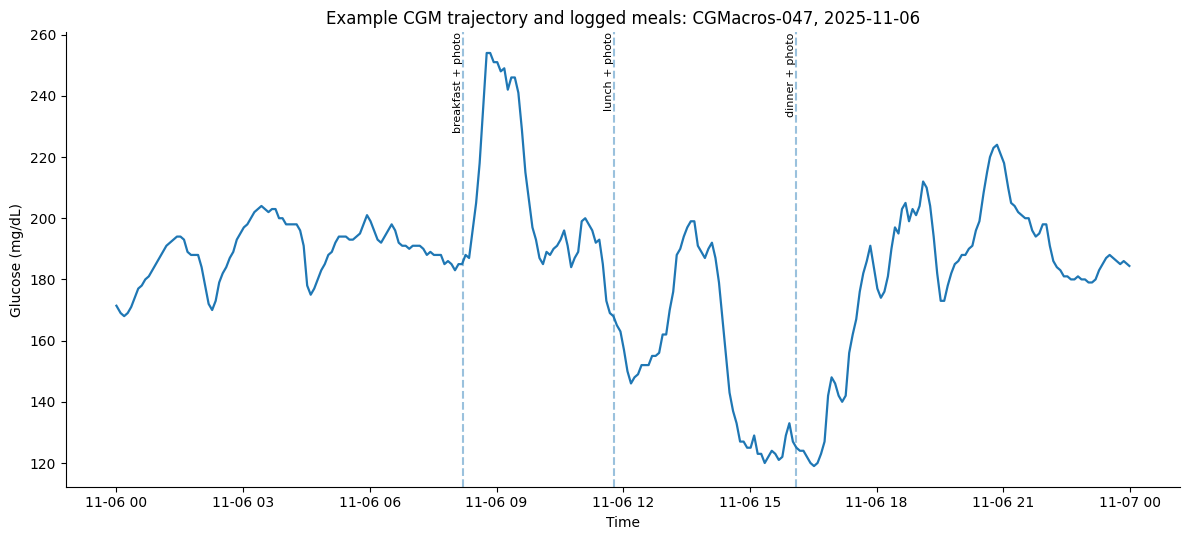

Selected example: CGMacros-047, 2025-11-06
          Timestamp Meal Type                                  Image path
2025-11-06 08:13:00 breakfast  photos/00000045-PHOTO-2025-11-6-8-13-0.jpg
2025-11-06 11:47:00     lunch photos/00000046-PHOTO-2025-11-6-11-47-0.jpg
2025-11-06 16:06:00    dinner  photos/00000050-PHOTO-2025-11-6-16-6-0.jpg


In [17]:
# Reproducibly select one participant-day containing photographed meals
rng_demo = np.random.default_rng(7)
eligible_days = []

for pid in kept_pids:
    df = pd.read_csv(cgm_root / pid / f'{pid}.csv')
    if not {'Timestamp', 'Dexcom GL', 'Meal Type', 'Image path'}.issubset(df.columns):
        continue
    df['Timestamp'] = pd.to_datetime(df['Timestamp'])
    df['date'] = df['Timestamp'].dt.date
    photographed = df[df['Meal Type'].notna() & df['Image path'].notna()]
    for day, g in photographed.groupby('date'):
        if len(g) >= 2:
            eligible_days.append((pid, day))

if not eligible_days:
    raise RuntimeError('No participant-day with at least two photographed meals was found.')

pid_demo, day_demo = eligible_days[int(rng_demo.integers(len(eligible_days)))]
df_demo = pd.read_csv(cgm_root / pid_demo / f'{pid_demo}.csv')
df_demo['Timestamp'] = pd.to_datetime(df_demo['Timestamp'])
day_start = pd.Timestamp(day_demo)
day_end = day_start + pd.Timedelta(days=1)
day_df = df_demo[(df_demo['Timestamp'] >= day_start) & (df_demo['Timestamp'] < day_end)].copy()
meal_demo = day_df[day_df['Meal Type'].notna()].copy()

plt.style.use('default')
fig, ax = plt.subplots(figsize=(12, 5.5), facecolor='white')
ax.plot(day_df['Timestamp'], day_df['Dexcom GL'], linewidth=1.6, label='Dexcom glucose')

for _, row in meal_demo.iterrows():
    has_photo = pd.notna(row['Image path'])
    ax.axvline(row['Timestamp'], linestyle='--', alpha=0.45)
    label = str(row['Meal Type']) + (' + photo' if has_photo else '')
    y_top = ax.get_ylim()[1]
    ax.text(row['Timestamp'], y_top, label, rotation=90, va='top', ha='right', fontsize=8)

ax.set_xlabel('Time')
ax.set_ylabel('Glucose (mg/dL)')
ax.set_title(f'Example CGM trajectory and logged meals: {pid_demo}, {day_demo}')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig(OUT_DIR / 'example_cgm_meal_alignment.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print(f'Selected example: {pid_demo}, {day_demo}')
print(meal_demo[['Timestamp', 'Meal Type', 'Image path']].to_string(index=False))


#### 7. Save analysis Summary

In [19]:
# Save final analysis summary and tabular outputs
summary_path = OUT_DIR / 'meal_photo_characteristics_summary.json'
with open(summary_path, 'w') as f:
    json.dump(summary, f, indent=2, default=str)

participant_meal.to_csv(
    OUT_DIR / 'meal_photo_counts_by_participant.csv'
)
group_summary.to_csv(
    OUT_DIR / 'meal_photo_summary_by_group.csv'
)
all42_images_df.to_csv(
    OUT_DIR / 'image_properties_all_physical_retained42.csv', index=False
)
meal_images_df.to_csv(
    OUT_DIR / 'image_properties_meal_associated_retained42.csv', index=False
)
meal_event_df.to_csv(
    OUT_DIR / 'meal_photo_coverage_retained42.csv', index=False
)
photo_structure.to_csv(
    OUT_DIR / 'tagged_untagged_counts_by_participant.csv', index=False
)
nutrition_availability.to_csv(
    OUT_DIR / 'nutrition_availability_by_participant_and_status.csv', index=False
)
nutrition_summary.to_csv(
    OUT_DIR / 'nutrition_availability_by_status.csv'
)

print(f'Saved summary to: {summary_path}')
print(f'Outputs directory: {OUT_DIR}')
print('Final save completed without legacy 45-participant variables.')


Saved summary to: /Users/ucabtt4/Projects/Dissertation/dissertation/dataset/analysis_outputs/meal_outputs/meal_photo_characteristics_summary.json
Outputs directory: /Users/ucabtt4/Projects/Dissertation/dissertation/dataset/analysis_outputs/meal_outputs
Final save completed without legacy 45-participant variables.


#### 食物图片分成 进餐前和进餐后 进餐前的图片是有meal type 食物信息的 所以先做 食物图片总的统计 这是一个数
然后统计有哪些meal type 明显是 dinner       418
snack        300
lunch        272
breakfast    266
Breakfast    170
Lunch        163
Dinner        74
Snacks        38
Snack          4
snack 1        1 明显是四种 breakfast lunch dinner snack 四种 所以把这些综合一下，给出一个统计数 然后 根据有meal type的统计一个数 所以其实核心就是 meal事件的的总数统计一下 有meal 的就是有meal type的地方 然后相应的会有照片的后面 然后统计一下 有照片的数量和没有照片的数量 就是这个就相当于照片的缺失 当然 这个是否计入我们最后的table 有待商榷 因为这个时候 我们应该对 42 个人进行处理 所以后续的所有实验都是基于我们上述说的42个人的 然后 就是 对剩余42个人做上述的一样的统计 就是统计一下 42 个人总共的meal 事件 和 meal type对应的image的数量和缺失量 这个基本的统计应该是做完了  然后我觉得我们需要出一个关于meal 数量上的 就是 42 个 的照片的平均数量 和 他们每个人的数量 我觉得这里需要出一些figure 保证数据的均衡 还有 分成不同healthy 啊之类的需要做嘛


#### 接下来是对meal 本身的性质进行一下探索 都是什么格式 什么样的mode 然后 大小 height file size等 然后探究出来 他们的分辨率是多少 是竖屏对吧 然后这是照片的基本信息对吧

#### 接下来 是我觉得 需要做的 就是关于 有 meal type 和 没有 meal type的一个区分吧 就是我们要说明 我们为什么不选取 那些不带meal type的输入进去 我觉得第一个直观的就是生成我们的这个照片来直观的展示 吃饭前的 照片和 吃饭后的照片的区别 吃饭后 就是展示 吃饭后的剩余 就是吃完饭后的照片没有什么额外的信息  所以我们不选 然后 第二个 我觉得 就是对于 nutrition 的statistics来说明吧

* 这里对于logged nutrition 的统计 可以直观的告诉我们 餐后的食物本身就没有记录额外的信息 所有的信息都记录在 有meal type的里面

#### 最后一步就是随机抽取一段时间 来展示 cgm 和 meal 的图像

In [ ]:
#### 最后一步就是随机抽取